# Rad-Scribe Pro — Notebook 4: Model B (EfficientNet-B3 + BioGPT)
**Symbiosis Institute of Technology | Dept. of AI & ML**

Team: Tejas Kale · Hardik Gulati · Swaraj Deogirkar | Mentor: Dr. Zulfikar Ali Ansari

### Why BioGPT over DistilGPT-2?
| | DistilGPT-2 | BioGPT |
|--|--|--|
| Trained on | General internet text | 15M PubMed biomedical papers |
| Vocabulary | General English | Medical terminology |
| Hidden size | 768 | 1024 |
| Medical terms | Split into subwords | Kept as single tokens |

BioGPT already knows radiology vocabulary — cardiomegaly, atelectasis, pneumothorax are single tokens not split into pieces. This means less hallucination and more accurate medical language.

### Architecture
```
Image (224×224)
  → EfficientNet-B3 (frozen except block 8)
  → Linear(1536 → 1024) + BatchNorm  ← matches BioGPT hidden size
  → prepend as visual token to BioGPT
  → BioGPT decoder (fine-tuned)
  → radiology report
```

> Run Notebook 2 first to generate parquet files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q datasets transformers torchvision tqdm nltk rouge-score bert-score
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('done')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.4 MB/s eta 0:00:00
done


In [ ]:
!pip install -q sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 20.4 MB/s eta 0:00:00


In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import BioGptTokenizer, BioGptForCausalLM, get_linear_schedule_with_warmup
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from datasets import load_dataset
from tqdm import tqdm
warnings.filterwarnings('ignore')

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR  = '/content/drive/MyDrive/Radscribe/radscribe_data'
MODEL_DIR = '/content/drive/MyDrive/Radscribe/radscribe_models'
os.makedirs(MODEL_DIR, exist_ok=True)
torch.manual_seed(42)
np.random.seed(42)
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda
GPU   : Tesla T4


In [ ]:
CFG = {
    'img_size'    : 224,
    'max_seq_len' : 128,
    'batch_size'  : 8,
    'epochs'      : 15,
    'patience'    : 4,
    'lr'          : 2e-5,
    'grad_clip'   : 1.0,
    'num_workers' : 2,
    'biogpt_hidden': 1024,   # BioGPT hidden size — different from DistilGPT-2's 768
}

# BioGPT tokenizer — trained on PubMed, knows medical vocabulary
print('Loading BioGPT tokenizer...')
tokenizer  = BioGptTokenizer.from_pretrained('microsoft/biogpt')
tokenizer.pad_token = tokenizer.eos_token
VOCAB_SIZE = tokenizer.vocab_size
PAD_ID     = tokenizer.pad_token_id
EOS_ID     = tokenizer.eos_token_id
BOS_ID     = tokenizer.bos_token_id

print(f'Vocab size : {VOCAB_SIZE:,}  (BioGPT biomedical vocab)')
print(f'PAD token  : {PAD_ID}')
print(f'EOS token  : {EOS_ID}')
print(f'BOS token  : {BOS_ID}')

# demonstrate BioGPT tokenizes medical terms better
test_terms = ['cardiomegaly', 'atelectasis', 'pneumothorax', 'cardiopulmonary']
print('\nTokenization comparison:')
for term in test_terms:
    biogpt_toks = tokenizer.tokenize(term)
    print(f'  {term:20s} → {biogpt_toks}')

Loading BioGPT tokenizer...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Vocab size : 42,384  (BioGPT biomedical vocab)
PAD token  : 2
EOS token  : 2
BOS token  : 0

Tokenization comparison:
  cardiomegaly         → ['cardi', 'omegaly</w>']
  atelectasis          → ['atelectasis</w>']
  pneumothorax         → ['pneumothorax</w>']
  cardiopulmonary      → ['cardiopulmonary</w>']


---
### Helper Functions

In [ ]:
def get_impression(report):
    t = str(report).upper()
    if 'IMPRESSION:' in t:
        idx = t.index('IMPRESSION:')
        return str(report)[idx+11:].strip()
    return str(report)

def classify(r):
    text = get_impression(r).lower()
    ABNORMAL = [
        'cardiomegaly','pneumonia','effusion','pneumothorax',
        'consolidation','atelectasis','opacity','infiltrate',
        'edema','fracture','nodule','mass','fibrosis',
        'hyperinflat','pleural','enlarged','tortuous',
        'degenerative','scoliosis','granuloma','calcif'
    ]
    NORMAL = [
        'no acute','normal','unremarkable','clear',
        'no significant','no evidence','negative',
        'within normal','no pneumothorax','no effusion',
        'no consolidation','no infiltrate'
    ]
    ab_hits = sum(1 for k in ABNORMAL if k in text)
    no_hits = sum(1 for k in NORMAL   if k in text)
    if ab_hits == 0 and no_hits == 0:
        full    = str(r).lower()
        ab_hits = sum(1 for k in ABNORMAL if k in full)
        no_hits = sum(1 for k in NORMAL   if k in full)
    if ab_hits > no_hits:  return 1
    if no_hits >= ab_hits: return 0
    return 2

def clean_output(text):
    sents = [s.strip() for s in text.split('.') if len(s.strip()) > 5]
    seen, unique = set(), []
    for s in sents:
        if s.lower() not in seen:
            seen.add(s.lower()); unique.append(s)
    return '. '.join(unique[:6]).strip() or 'No findings'

print('Helper functions ready')

Helper functions ready


---
### Data Loading

In [ ]:
df_train = pd.read_parquet(f'{DATA_DIR}/train.parquet')
df_val   = pd.read_parquet(f'{DATA_DIR}/val.parquet')
df_test  = pd.read_parquet(f'{DATA_DIR}/test.parquet')
df_train['split'] = 'train'
df_val  ['split'] = 'train'
df_test ['split'] = 'test'

print('Loading HF dataset...')
raw = load_dataset('MLforHealthcare/Indiana_University_Chest_X-ray_Collection')
print(f'Train {len(df_train):,} | Val {len(df_val):,} | Test {len(df_test):,}')
print('Class dist:', df_train['label'].value_counts().to_dict())

Loading HF dataset...


README.md:   0%|          | 0.00/463 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/407M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/411M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/410M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/135M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6687 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/743 [00:00<?, ? examples/s]

Train 4,308 | Val 1,004 | Test 743
Class dist: {0: 2872, 1: 1436}


In [ ]:
TRAIN_TF = T.Compose([
    T.Resize((CFG['img_size'], CFG['img_size'])),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
EVAL_TF = T.Compose([
    T.Resize((CFG['img_size'], CFG['img_size'])),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class CXRDataset(Dataset):
    def __init__(self, df, hf_raw, transform):
        self.df        = df.reset_index(drop=True)
        self.hf_raw    = hf_raw
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img    = self.hf_raw[row['split']][int(row['hf_index'])]['image'].convert('RGB')
        img    = self.transform(img)
        report = str(row['report'])

        # tokenize with BioGPT tokenizer
        enc = tokenizer(
            report,
            max_length     = CFG['max_seq_len'],
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        return {
            'image'    : img,
            'input_ids': enc['input_ids'].squeeze(0),
            'report'   : report,
            'label'    : torch.tensor(classify(report), dtype=torch.long)
        }

# weighted sampler — fixes class imbalance
train_labels_arr = np.array([classify(r) for r in df_train['report']])
counts    = np.bincount(train_labels_arr, minlength=3)
class_w   = 1.0 / (counts + 1e-6)
sample_w  = class_w[train_labels_arr]
sampler   = WeightedRandomSampler(torch.DoubleTensor(sample_w), len(sample_w), replacement=True)

train_ds = CXRDataset(df_train, raw, TRAIN_TF)
val_ds   = CXRDataset(df_val,   raw, EVAL_TF)
test_ds  = CXRDataset(df_test,  raw, EVAL_TF)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], sampler=sampler,
                          num_workers=CFG['num_workers'], pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)
print(f'Train {len(train_loader)} | Val {len(val_loader)} | Test {len(test_loader)} batches')

Train 538 | Val 126 | Test 93 batches


In [ ]:
# verify sampler
from collections import Counter
lc = Counter()
for i, b in enumerate(train_loader):
    if i >= 50: break
    for l in b['label'].numpy(): lc[l] += 1
ratio = lc[1] / (lc[0] + 1e-6)
print(f'Normal:{lc[0]}  Abnormal:{lc[1]}  ratio:{ratio:.2f}  (good if > 0.6)')

Normal:208  Abnormal:192  ratio:0.92  (good if > 0.6)


---
### Model Architecture

In [ ]:
class EncoderEfficientNet(nn.Module):
    """
    EfficientNet-B3 image encoder.
    Projects 1536-dim features to 1024-dim to match BioGPT hidden size.
    Only last block (block 8) is trainable — rest frozen to preserve ImageNet features.
    """
    def __init__(self, out_dim):
        super().__init__()
        base          = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.features = base.features
        self.pool     = base.avgpool
        self.proj     = nn.Linear(1536, out_dim)
        self.bn       = nn.BatchNorm1d(out_dim, momentum=0.01)
        # freeze all except block 8 (last feature block)
        for name, p in self.features.named_parameters():
            p.requires_grad = name.startswith('8')

    def forward(self, x):
        return self.bn(self.proj(self.pool(self.features(x)).flatten(1)))


class ModelB(nn.Module):
    """
    Model B: EfficientNet-B3 + BioGPT

    Image is encoded to 1024-dim vector (matching BioGPT hidden size).
    This vector is prepended as a visual token before the report tokens.
    BioGPT then generates the report conditioned on both image and context.

    Key improvement over DistilGPT-2: BioGPT was pretrained on 15M PubMed
    papers so it already understands medical terminology as single tokens.
    """
    def __init__(self, cfg):
        super().__init__()
        self.encoder = EncoderEfficientNet(cfg['biogpt_hidden'])
        self.decoder = BioGptForCausalLM.from_pretrained('microsoft/biogpt')

    def forward(self, images, input_ids, sample_labels=None):
        img_feat      = self.encoder(images)                              # [B, 1024]
        img_token     = img_feat.unsqueeze(1)                             # [B, 1, 1024]
        tok_emb       = self.decoder.biogpt.embed_tokens(input_ids)       # [B, T, 1024]
        inputs_embeds = torch.cat([img_token, tok_emb], dim=1)            # [B, T+1, 1024]

        # explicit attention mask
        img_mask  = torch.ones(images.size(0), 1,
                               device=images.device, dtype=torch.long)
        text_mask = (input_ids != PAD_ID).long()
        full_mask = torch.cat([img_mask, text_mask], dim=1)

        # mask PAD tokens from loss
        labels        = input_ids.clone()
        labels[labels == PAD_ID] = -100
        labels        = torch.cat([
            torch.full((input_ids.size(0), 1), -100, device=input_ids.device),
            labels
        ], dim=1)

        out  = self.decoder(inputs_embeds=inputs_embeds,
                            attention_mask=full_mask, labels=labels)
        loss = out.loss

        # weighted loss — Abnormal cases get 2x penalty
        if sample_labels is not None:
            w = torch.where(
                sample_labels.to(loss.device) == 1,
                torch.tensor(2.0, device=loss.device),
                torch.tensor(1.0, device=loss.device)
            )
            loss = loss * w.mean()

        return loss, out.logits

    @torch.no_grad()
    def generate(self, img_tensor, max_new_tokens=100):
        self.eval()
        img       = img_tensor.unsqueeze(0).to(DEVICE)
        img_feat  = self.encoder(img)
        img_token = img_feat.unsqueeze(1)                                  # [1, 1, 1024]

        # start with BOS token embedding
        start_emb = self.decoder.biogpt.embed_tokens(
                        torch.tensor([[BOS_ID]], device=DEVICE))           # [1, 1, 1024]
        embeds    = torch.cat([img_token, start_emb], dim=1)               # [1, 2, 1024]
        attn_mask = torch.ones(embeds.shape[:2], device=DEVICE, dtype=torch.long)

        gen_ids = self.decoder.generate(
            inputs_embeds        = embeds,
            attention_mask       = attn_mask,
            max_new_tokens       = max_new_tokens,
            min_new_tokens       = 15,
            no_repeat_ngram_size = 4,
            num_beams            = 4,
            early_stopping       = True,
            do_sample            = False,
            eos_token_id         = EOS_ID,
            pad_token_id         = PAD_ID,
        )
        return clean_output(tokenizer.decode(gen_ids[0], skip_special_tokens=True))


print('Loading BioGPT model...')
model_b   = ModelB(CFG).to(DEVICE)
total_p   = sum(p.numel() for p in model_b.parameters())
trainable = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
print(f'Total params    : {total_p:,}')
print(f'Trainable params: {trainable:,}')
print(f'Frozen params   : {total_p - trainable:,}')

Loading BioGPT model...
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 123MB/s]


config.json:   0%|          | 0.00/595 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie biogpt.embed_tokens.weight to output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Total params    : 402,436,648
Trainable params: 392,333,312
Frozen params   : 10,103,336


---
### Optimizer + Scheduler

In [ ]:
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model_b.parameters()),
    lr           = CFG['lr'],
    weight_decay = 0.01
)
total_steps  = CFG['epochs'] * len(train_loader)
warmup_steps = int(0.1 * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)
print(f'LR          : {CFG["lr"]}')
print(f'Warmup steps: {warmup_steps}')
print(f'Total steps : {total_steps}')

LR          : 2e-05
Warmup steps: 807
Total steps : 8070


---
### Training Loop

In [ ]:
history       = {'train': [], 'val': []}
best_val_loss = float('inf')
patience_ctr  = 0

for epoch in range(1, CFG['epochs'] + 1):
    model_b.train()
    running = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{CFG["epochs"]} [Train]')
    for batch in pbar:
        images = batch['image'].to(DEVICE)
        caps   = batch['input_ids'].to(DEVICE)
        lbs    = batch['label'].to(DEVICE)
        optimizer.zero_grad()
        loss, _ = model_b(images, caps, sample_labels=lbs)
        loss.backward()
        nn.utils.clip_grad_norm_(model_b.parameters(), CFG['grad_clip'])
        optimizer.step()
        scheduler.step()
        running += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')
    train_loss = running / len(train_loader)

    model_b.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Val', leave=False):
            loss, _ = model_b(batch['image'].to(DEVICE), batch['input_ids'].to(DEVICE))
            val_loss += loss.item()
    val_loss /= len(val_loader)

    history['train'].append(round(train_loss, 4))
    history['val'  ].append(round(val_loss,   4))
    print(f'Epoch {epoch}  Train: {train_loss:.4f}  Val: {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr  = 0
        torch.save(model_b.state_dict(), f'{MODEL_DIR}/model_b_best.pth')
        print(f'  checkpoint saved (val: {best_val_loss:.4f})')
    else:
        patience_ctr += 1
        print(f'  no improvement (patience {patience_ctr}/{CFG["patience"]})')
        if patience_ctr >= CFG['patience']:
            print(f'  early stopping at epoch {epoch}')
            break

torch.save(model_b.state_dict(), f'{MODEL_DIR}/model_b_final.pth')
print(f'\nDone. Best val loss: {best_val_loss:.4f}')
print('Train:', history['train'])
print('Val  :', history['val'])

Epoch 1/15 [Train]: 100%|██████████| 538/538 [08:19<00:00,  1.08it/s, loss=2.1679]


Epoch 1  Train: 3.2064  Val: 1.3007
  checkpoint saved (val: 1.3007)


Epoch 2/15 [Train]: 100%|██████████| 538/538 [08:25<00:00,  1.06it/s, loss=1.4762]


Epoch 2  Train: 1.8388  Val: 1.0773
  checkpoint saved (val: 1.0773)


Epoch 3/15 [Train]: 100%|██████████| 538/538 [08:26<00:00,  1.06it/s, loss=1.2377]


...

Epoch 13  Train: 0.3387  Val: 0.6612
  no improvement (patience 1/4)


Epoch 14/15 [Train]: 100%|██████████| 538/538 [08:25<00:00,  1.07it/s, loss=0.3069]


Epoch 14  Train: 0.3205  Val: 0.6473
  checkpoint saved (val: 0.6473)


Epoch 15/15 [Train]: 100%|██████████| 538/538 [08:27<00:00,  1.06it/s, loss=0.4227]


Epoch 15  Train: 0.3141  Val: 0.6449
  checkpoint saved (val: 0.6449)

Done. Best val loss: 0.6449
Train: [3.2064, 1.8388, 1.3711, 1.0429, 0.8617, 0.7009, 0.5936, 0.5085, 0.4538, 0.4198, 0.3817, 0.356, 0.3387, 0.3205, 0.3141]
Val  : [1.3007, 1.0773, 0.9478, 0.8842, 0.8018, 0.7549, 0.7301, 0.6957, 0.6936, 0.6728, 0.6695, 0.6583, 0.6612, 0.6473, 0.6449]


---
### Loss Curve

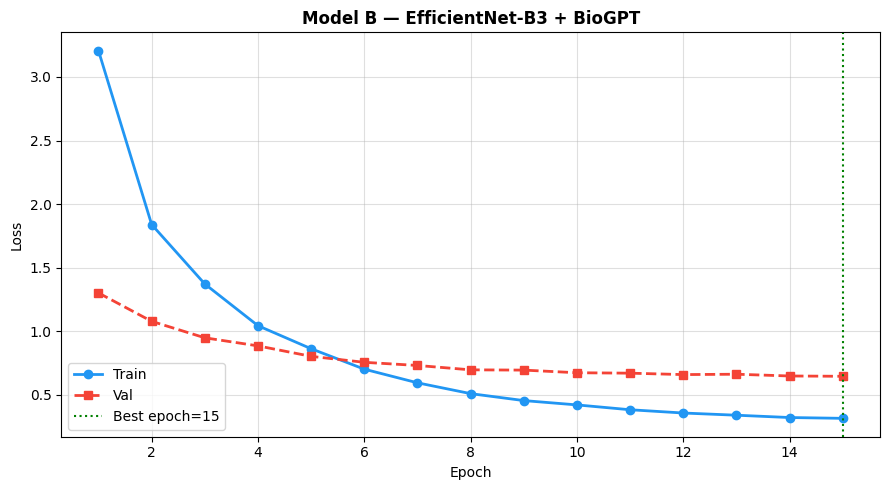

In [ ]:
ep = range(1, len(history['train']) + 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ep, history['train'], 'o-', color='#2196F3', linewidth=2, label='Train')
ax.plot(ep, history['val'],   's--', color='#F44336', linewidth=2, label='Val')
best_ep = history['val'].index(min(history['val'])) + 1
ax.axvline(best_ep, color='green', linestyle=':', linewidth=1.5,
           label=f'Best epoch={best_ep}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Model B — EfficientNet-B3 + BioGPT', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

---
### Quick Generation Test

In [ ]:
model_b.load_state_dict(torch.load(f'{MODEL_DIR}/model_b_best.pth', map_location=DEVICE))
model_b.eval()

print('Generation test (5 samples):')
outputs = []
for i in range(5):
    s = test_ds[i]
    g = model_b.generate(s['image'])
    outputs.append(g)
    print(f'[{i}] GT : {s["report"][:100]}')
    print(f'     Gen: {g}')
    print()

print(f'Unique outputs: {len(set(outputs))}/5')
print('Varied = good | All same = lazy model | Empty = generation bug')

Generation test (5 samples):
[0] GT : FINDINGS: . IMPRESSION: Heart size is normal and lungs are clear. No infiltrates or atelectasis. Gal
     Gen: Exaggerated kyphosis. No focal consolidation, suspicious pulmonary opacity, pneumothorax or definite pleural effusion. Heart size and pulmonary vascularity within normal limits, visualized osseous structures appear intact. IMPRESSION: No acute cardiopulmonary abnormality. Kyphotic curvature without acute displaced rib fracture. No acute displaced vertebral fracture demonstrated

[1] GT : FINDINGS: Lung volumes are . opacities are present in both lung bases. A hiatal hernia is present. H
     Gen: Unchanged interstitial opacities. No pneumothorax or pleural effusion. No acute osseous findings. IMPRESSION: Unchanged appearance of the chest with interstitial prominence the differential of which is but could include interstitial edema, infectious process or interstitial disease. CT may be helpful for further evaluation. No acute bony findings


---
### Evaluation — BLEU, ROUGE-L, BERTScore

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rs
from bert_score import score as bert_score

safe_len = (df_test['hf_index'] < len(raw['test'])).sum()
N_EVAL   = min(200, safe_len)
refs, hyps = [], []

print(f'Generating {N_EVAL} reports...')
for i in tqdm(range(N_EVAL)):
    s = test_ds[i]
    g = model_b.generate(s['image'])
    refs.append(s['report'])
    hyps.append(g if g.strip() else 'no findings')

smooth = SmoothingFunction().method1
rt     = [[r.lower().split()] for r in refs]
ht     = [h.lower().split()   for h in hyps]
b1 = corpus_bleu(rt, ht, weights=(1,0,0,0),             smoothing_function=smooth)
b2 = corpus_bleu(rt, ht, weights=(0.5,0.5,0,0),         smoothing_function=smooth)
b3 = corpus_bleu(rt, ht, weights=(0.33,0.33,0.33,0),    smoothing_function=smooth)
b4 = corpus_bleu(rt, ht, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth)

scorer    = rs.RougeScorer(['rougeL'], use_stemmer=True)
rl_scores = [scorer.score(r, h)['rougeL'] for r, h in zip(refs, hyps)]
rl_f1     = sum(s.fmeasure for s in rl_scores) / len(rl_scores)

print('Computing BERTScore...')
P, R, F1 = bert_score(hyps, refs, lang='en',
                       model_type='distilbert-base-uncased', verbose=False)
bs_f1 = F1.mean().item()

print()
print('=' * 50)
print('MODEL B — RESULTS')
print(f'  Eval samples : {N_EVAL}')
print('=' * 50)
print(f'  BLEU-1       : {b1:.4f}')
print(f'  BLEU-2       : {b2:.4f}')
print(f'  BLEU-3       : {b3:.4f}')
print(f'  BLEU-4       : {b4:.4f}')
print(f'  ROUGE-L F1   : {rl_f1:.4f}')
print(f'  BERTScore F1 : {bs_f1:.4f}')
print('=' * 50)

scores_b = {
    'bleu1': round(b1,4), 'bleu2': round(b2,4),
    'bleu3': round(b3,4), 'bleu4': round(b4,4),
    'rougeL_f1': round(rl_f1,4), 'bertscore_f1': round(bs_f1,4)
}
with open(f'{MODEL_DIR}/scores_b.json', 'w') as f:
    json.dump(scores_b, f, indent=2)
print('Saved scores_b.json')

Generating 200 reports...


100%|██████████| 200/200 [06:44<00:00,  2.02s/it]


Computing BERTScore...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



MODEL B — RESULTS
  Eval samples : 200
  BLEU-1       : 0.2500
  BLEU-2       : 0.1365
  BLEU-3       : 0.0850
  BLEU-4       : 0.0517
  ROUGE-L F1   : 0.2244
  BERTScore F1 : 0.8403
Saved scores_b.json


---
### Clinical Label Accuracy

In [ ]:
# check if model generates correct Normal/Abnormal classification
correct = sum(1 for r, h in zip(refs, hyps) if classify(r) == classify(h))
print(f'Clinical label agreement: {correct}/{len(refs)} = {correct/len(refs)*100:.1f}%')
print('How often the generated report matches Normal/Abnormal of ground truth')
print()
print('MODEL B SUMMARY')
print(f'  Architecture : EfficientNet-B3 + BioGPT')
print(f'  Decoder      : microsoft/biogpt (15M PubMed papers)')
print(f'  Checkpoint   : {MODEL_DIR}/model_b_best.pth')
print(f'  Next step    : Notebook 5 — build FAISS embeddings for RAG')

Clinical label agreement: 107/200 = 53.5%
How often the generated report matches Normal/Abnormal of ground truth

MODEL B SUMMARY
  Architecture : EfficientNet-B3 + BioGPT
  Decoder      : microsoft/biogpt (15M PubMed papers)
  Checkpoint   : /content/drive/MyDrive/Radscribe/radscribe_models/model_b_best.pth
  Next step    : Notebook 5 — build FAISS embeddings for RAG
